# Лабораторная работа 11

Тема: **Автоэнкодер для изображений MNIST в PyTorch**  
Формат: практическая работа с обязательными собственными комментариями и экспериментами.

> Этот ноутбук специально оформлен так, чтобы **нельзя было сделать отчёт простым копированием чужого кода или ответов генеративной модели**.  
> Каркас кода даёт вам рабочий пример, но оцениваться будут **ваши** настройки, эксперименты и живые текстовые объяснения.


## 1. Ваши ожидания от автоэнкодера

Перед запуском кода сформулируйте текущие ожидания (6–10 предложений):

1. Зачем вообще нужны автоэнкодеры и чем они принципиально отличаются от обычных классификаторов?
2. Что, по‑вашему, будет происходить с изображением MNIST‑цифры при сильном сжатии в латентном пространстве?  
3. Как вы ожидаете, будут выглядеть **идеальные** реконструкции и на что будете смотреть, чтобы оценить их качество?

In [1]:
intro_text = """
1) Классификатор определяет, что изображено на картинке, 
а автоэнкодеры пытаются сжать изображение и затем восстановить его как можно точнее.
2) Если сильно уменьшить размер латентного пространства, часть информации потеряется. 
Думаю сеть сохранит только самые важные признаки цифры.
3) Хорошая реконструкция должна быть похожа на оригинал и оставаться легко узнаваемой. 
Буду смотреть на сохранность важных деталей.
"""
print(intro_text)


1) Классификатор определяет, что изображено на картинке, 
а автоэнкодеры пытаются сжать изображение и затем восстановить его как можно точнее.
2) Если сильно уменьшить размер латентного пространства, часть информации потеряется. 
Думаю сеть сохранит только самые важные признаки цифры.
3) Хорошая реконструкция должна быть похожа на оригинал и оставаться легко узнаваемой. 
Буду смотреть на сохранность важных деталей.



## 2. Импорт библиотек и настройка среды


In [2]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

MY_SEED = 11
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 11


## 3. Данные MNIST и DataLoader

Используем стандартный MNIST (28×28, оттенки серого).  
Автоэнкодер будет учиться восстанавливать картинку **самой себя**.


In [3]:
batch_size = 256

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))

Размер train: 60000
Размер test : 10000


Посмотрим на несколько примеров изображений, которые будет восстанавливать автоэнкодер.


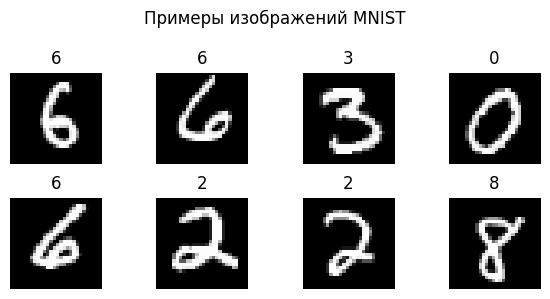

In [4]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(str(labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным

Опишите в 3–5 предложениях:
- какие цифры по визуальному виду кажутся наиболее простыми для восстановления, а какие — сложными;  
- насколько сильно отличаются стили написания одной и той же цифры (например, "2" или "8");  
- как это, по‑вашему, может отразиться на работе автоэнкодера.


In [5]:
data_comment = """
По картинкам мне кажется, что цифры 0 и 6 самые простые для восстановления.
Цифры 2 и 8 выглядят более разнообразно, поэтому с ними может быть больше ошибок.
Видно, что одну и ту же цифру разные люди пишут немного по-разному.
Из-за этого автоэнкодеру будет сложнее точно восстановить некоторые изображения.
"""
print(data_comment)


По картинкам мне кажется, что цифры 0 и 6 самые простые для восстановления.
Цифры 2 и 8 выглядят более разнообразно, поэтому с ними может быть больше ошибок.
Видно, что одну и ту же цифру разные люди пишут немного по-разному.
Из-за этого автоэнкодеру будет сложнее точно восстановить некоторые изображения.



## 4. Архитектура простого полносвязного автоэнкодера

Будем работать с векторизованным изображением размерности 784 (28×28).  
Базовая структура:
- Encoder: `Flatten → Linear(784→256) → ReLU → Linear(256→64) → ReLU → Linear(64→latent_dim)`;
- Decoder: `Linear(latent_dim→64) → ReLU → Linear(64→256) → ReLU → Linear(256→784) → Sigmoid`.

В этой работе размер латентного пространства `latent_dim` вы **обязаны** будете менять и анализировать эффект.


In [6]:
latent_dim = 16  # базовое значение; в отчёте попробуйте хотя бы ещё два

class FCN_Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid(),  # пиксели в 
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out, z

model = FCN_Autoencoder(latent_dim=latent_dim).to(device)
print(model)

FCN_Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### Обсуждение архитектуры

Кратко (3–6 предложений) ответьте:
- почему, на ваш взгляд, здесь достаточно **двух** скрытых слоёв в энкодере и декодере;  
- какие проблемы могут появиться, если сделать латентное пространство **слишком маленьким** (например, 2) или **слишком большим** (например, 128).


In [7]:
arch_comment = """
Для MNIST двух скрытых слоёв достаточно, так как цифры имеют простую структуру.
Постепенное уменьшение размерности помогает сохранить важные признаки изображения.

Слишком маленький latent_dim приводит к потере информации и размытым реконструкциям.
Слишком большой latent_dim уменьшает эффект сжатия, и модель начинает больше запоминать данные,
чем выделять действительно важные признаки.
"""
print(arch_comment)


Для MNIST двух скрытых слоёв достаточно, так как цифры имеют простую структуру.
Постепенное уменьшение размерности помогает сохранить важные признаки изображения.

Слишком маленький latent_dim приводит к потере информации и размытым реконструкциям.
Слишком большой latent_dim уменьшает эффект сжатия, и модель начинает больше запоминать данные,
чем выделять действительно важные признаки.



## 5. Функция потерь, оптимизатор и цикл обучения

Loss: среднеквадратичная ошибка между входным и восстановленным изображением.  
Оптимизатор: Adam с умеренным шагом.


In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for images, _ in dataloader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    return total_loss / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs, _ = model(images)
            loss = criterion(outputs, images)
            total_loss += loss.item() * images.size(0)
            total += images.size(0)
    return total_loss / total

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


In [9]:
num_epochs = 15
history = {"train_loss": [], "test_loss": []}

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)

    print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")

Эпоха 1/15: train_loss=0.0670, test_loss=0.0411
Эпоха 2/15: train_loss=0.0337, test_loss=0.0290
Эпоха 3/15: train_loss=0.0265, test_loss=0.0245
Эпоха 4/15: train_loss=0.0237, test_loss=0.0222
Эпоха 5/15: train_loss=0.0217, test_loss=0.0205
Эпоха 6/15: train_loss=0.0201, test_loss=0.0189
Эпоха 7/15: train_loss=0.0187, test_loss=0.0176
Эпоха 8/15: train_loss=0.0174, test_loss=0.0164
Эпоха 9/15: train_loss=0.0162, test_loss=0.0155
Эпоха 10/15: train_loss=0.0154, test_loss=0.0150
Эпоха 11/15: train_loss=0.0148, test_loss=0.0143
Эпоха 12/15: train_loss=0.0143, test_loss=0.0140
Эпоха 13/15: train_loss=0.0139, test_loss=0.0136
Эпоха 14/15: train_loss=0.0136, test_loss=0.0132
Эпоха 15/15: train_loss=0.0132, test_loss=0.0131


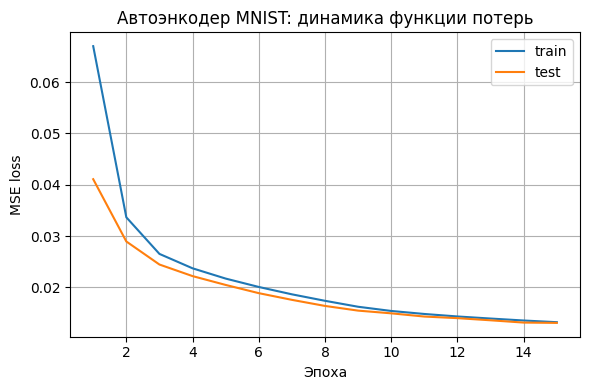

Финальные значения: train_loss=0.0132, test_loss=0.0131


In [10]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Автоэнкодер MNIST: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={history['train_loss'][-1]:.4f}, test_loss={history['test_loss'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- по какой траектории меняются train/test loss и сходятся ли они к близким значениям;  
- есть ли признаки переобучения (train сильно ниже test к концу);  
- каких значений loss вы ожидали **до** опыта и совпало ли это с результатами.


In [24]:
training_comment = """
1) Train и test loss уменьшаются плавно на протяжении всего обучения. На первой эпохе
они были 0.0670 и 0.0411, а уже к 5 эпохе снизились до 0.0217 и 0.0205.
Дальше улучшение продолжалось, хотя и медленнее.
К концу обучения значения практически совпали: train_loss = 0.0132, test_loss = 0.0131.
Это говорит о том, что модель хорошо обобщает данные.

2) Признаков переобучения не видно, так как test loss не начинает расти,
а разрыв между train и test остаётся минимальным на всех эпохах.

3) До эксперимента я ожидала, что итоговый loss будет примерно в диапазоне
0.01–0.02. Результат оказался близким к ожиданиям: модель смогла снизить ошибку до 0.013.
"""
print(training_comment)


1) Train и test loss уменьшаются плавно на протяжении всего обучения. На первой эпохе
они были 0.0670 и 0.0411, а уже к 5 эпохе снизились до 0.0217 и 0.0205.
Дальше улучшение продолжалось, хотя и медленнее.
К концу обучения значения практически совпали: train_loss = 0.0132, test_loss = 0.0131.
Это говорит о том, что модель хорошо обобщает данные.

2) Признаков переобучения не видно, так как test loss не начинает расти,
а разрыв между train и test остаётся минимальным на всех эпохах.

3) До эксперимента я ожидала, что итоговый loss будет примерно в диапазоне
0.01–0.02. Результат оказался близким к ожиданиям: модель смогла снизить ошибку до 0.013.



## 6. Визуализация реконструкций

Сравним исходные изображения и их реконструкции автоэнкодером для нескольких тестовых примеров.


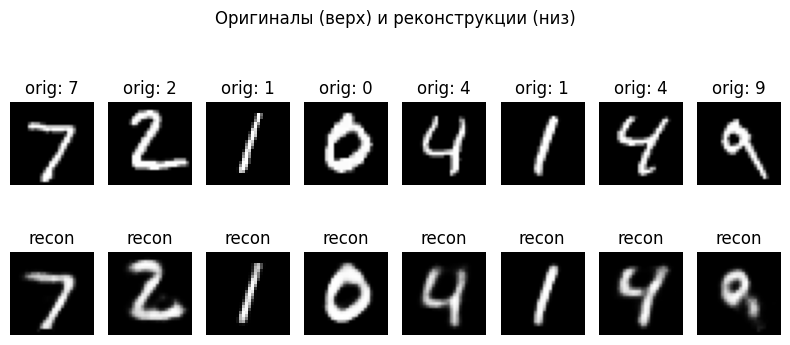

In [12]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)
with torch.no_grad():
    reconstructions, _ = model(images)

images = images.cpu()
reconstructions = reconstructions.cpu()

n = 8
plt.figure(figsize=(8, 4))
for i in range(n):
    # оригинал
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"orig: {labels[i].item()}")
    plt.axis("off")
    # реконструкция
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructions[i].squeeze(0), cmap="gray")
    plt.title("recon")
    plt.axis("off")
plt.suptitle("Оригиналы (верх) и реконструкции (низ)")
plt.tight_layout()
plt.show()

### Качественная оценка реконструкций

Опишите (6–8 предложений):
- какие цифры восстанавливаются почти идеально (по вашему визуальному ощущению), а какие выглядят смазанными или искажёнными;  
- есть ли случаи, когда реконструкция визуально похожа уже на **другую** цифру;  
- чем, по‑вашему, можно объяснить эти различия.


In [25]:
recon_comment = """
1) Большинство цифр восстанавливаются довольно хорошо. Почти не отличаются от оригиналов и остаются легко узнаваемыми.
Небольшие искажения заметны у цифры 9. Контуры стали более размытыми.

2) Визуально все реконструкции всё ещё похожи на исходные цифры, поэтому случаев,
когда одна цифра стала похожа на другую, на этих примерах практически нет.

3) Различия можно объяснить тем, что автоэнкодер хранит изображение в сжатом виде.
При восстановлении он сохраняет основные черты цифры, но может терять мелкие детали
и делать изображение более сглаженным.
"""
print(recon_comment)


1) Большинство цифр восстанавливаются довольно хорошо. Почти не отличаются от оригиналов и остаются легко узнаваемыми.
Небольшие искажения заметны у цифры 9. Контуры стали более размытыми.

2) Визуально все реконструкции всё ещё похожи на исходные цифры, поэтому случаев,
когда одна цифра стала похожа на другую, на этих примерах практически нет.

3) Различия можно объяснить тем, что автоэнкодер хранит изображение в сжатом виде.
При восстановлении он сохраняет основные черты цифры, но может терять мелкие детали
и делать изображение более сглаженным.



## 7. Латентное пространство: PCA‑проекция в 2D

Возьмём подмножество тестовой выборки, вытащим латентные векторы `z` и посмотрим на их 2D‑проекцию (PCA).  
Цель: увидеть, группируются ли разные цифры в отдельные кластеры.


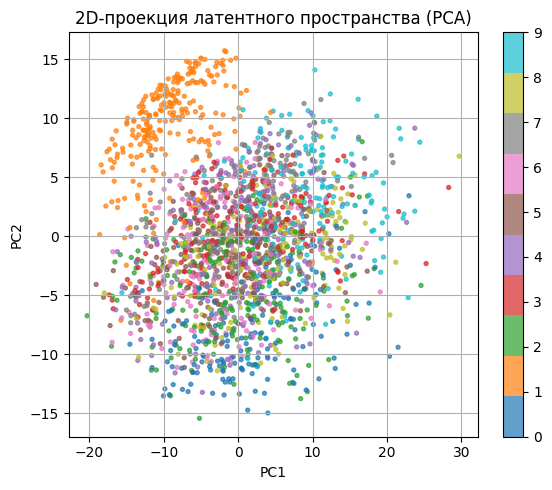

In [14]:
from sklearn.decomposition import PCA

model.eval()
all_z = []
all_y = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        all_z.append(z.cpu().numpy())
        all_y.append(labels.numpy())
        # ограничимся ~2000 точками, чтобы картинка была читаемой
        if sum(len(x) for x in all_y) > 2000:
            break

Z = np.vstack(all_z)
Y = np.hstack(all_y)

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D‑проекция латентного пространства (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

### Интерпретация латентного пространства

Ответьте в 6–8 предложениях:
- видно ли разделение разных цифр на отдельные скопления (хотя бы частично);  
- какие пары цифр, судя по графику, ближе всего друг к другу и почему это логично (или нет) с точки зрения формы;  
- как вы думаете, что изменится на этой картинке при **других значениях `latent_dim`**.


In [27]:
latent_comment = """
1) Полного разделения цифр на отдельные группы не видно. Некоторые цифры образуют
небольшие скопления, но большая часть точек разных классов пересекается между собой.

2) Ближе всего друг к другу находятся цифры с похожей формой, например 3, 5, 8 и 9,
так как у них есть общие округлые элементы и похожие контуры.
Лучше остальных выделяется цифра 1. Её точки чаще располагаются отдельно,
потому что по форме она проще большинства других цифр.

3) При большом latent_dim модель запоминает больше деталей, поэтому разные цифры
могут лучше отделяться друг от друга. 
При маленьком latent_dim информации становится меньше, поэтому цифры сильнее
смешиваются, а качество ухудшается.
"""
print(latent_comment)


1) Полного разделения цифр на отдельные группы не видно. Некоторые цифры образуют
небольшие скопления, но большая часть точек разных классов пересекается между собой.

2) Ближе всего друг к другу находятся цифры с похожей формой, например 3, 5, 8 и 9,
так как у них есть общие округлые элементы и похожие контуры.
Лучше остальных выделяется цифра 1. Её точки чаще располагаются отдельно,
потому что по форме она проще большинства других цифр.

3) При большом latent_dim модель запоминает больше деталей, поэтому разные цифры
могут лучше отделяться друг от друга. 
При маленьком latent_dim информации становится меньше, поэтому цифры сильнее
смешиваются, а качество ухудшается.



## 8. Генерация новых изображений из латентного пространства

Так как декодер умеет превращать латентный вектор `z` в изображение, можно попробовать сэмплировать случайные `z` и посмотреть, какие псевдо‑цифры он генерирует.


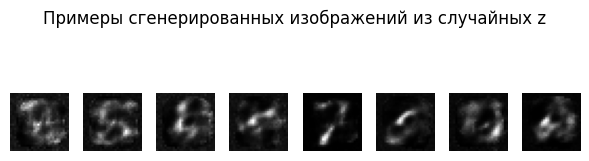

In [16]:
model.eval()
n_samples = 8

# сэмплируем z из N(0, 1)
z_random = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    decoded = model.decoder(z_random)
    decoded = decoded.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(6, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(decoded[i].squeeze(0), cmap="gray")
    plt.axis("off")
plt.suptitle("Примеры сгенерированных изображений из случайных z")
plt.tight_layout()
plt.show()

### Обсуждение качества генерации

Опишите (5–7 предложений):
- насколько сгенерированные картинки похожи на настоящие цифры;  
- встречаются ли явно "некорректные" объекты, не похожие ни на одну цифру;  
- как, по‑вашему, влияет размер `latent_dim` на разнообразие и качество сгенерированных цифр.


In [28]:
gen_comment = """
1) Сгенерированные изображения частично похожи на настоящие цифры, но большинство из них выглядят размытыми.
Лучше всего узнаются цифры, похожие на 7, 5 или 8, все остальное выглядит нечётко.

2) Есть неудачные примеры, которые больше похожи на набор светлых линий и пятен, чем на конкретную цифру.
Это можно объяснить тем, что автоэнкодер учится восстанавливать реальные изображения, а не создавать новые.

3) При большем latent_dim качество генерации может стать лучше, так как модель хранит больше информации. 
Если latent_dim сделать слишком маленьким, изображения станут ещё более размытыми и менее похожими на цифры.
"""
print(gen_comment)


1) Сгенерированные изображения частично похожи на настоящие цифры, но большинство из них выглядят размытыми.
Лучше всего узнаются цифры, похожие на 7, 5 или 8, все остальное выглядит нечётко.

2) Есть неудачные примеры, которые больше похожи на набор светлых линий и пятен, чем на конкретную цифру.
Это можно объяснить тем, что автоэнкодер учится восстанавливать реальные изображения, а не создавать новые.

3) При большем latent_dim качество генерации может стать лучше, так как модель хранит больше информации. 
Если latent_dim сделать слишком маленьким, изображения станут ещё более размытыми и менее похожими на цифры.



## 9. Задание для самостоятельных вариаций

В **своём** варианте лабораторной вы должны будете:

- попробовать **не меньше двух дополнительных** значений `latent_dim` (например, 2 и 64) и сравнить:  
  - динамику loss,  
  - качество реконструкций,  
  - вид латентного пространства;  
- изменить архитектуру (добавить слои, поменять размеры, попробовать другой activation на скрытых слоях) и кратко описать, что изменилось;  
- оформить итоговые выводы так, чтобы через полгода, открыв ноутбук, вы по нескольким абзацам **вспомнили весь ход экспериментов**.


In [18]:
# ── Общие функции ─────────────────────────────────────────────

def train_ae(model, name, epochs=15):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    hist = {"train": [], "test": []}

    for ep in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, optimizer, criterion, device)
        te = evaluate(model, test_loader, criterion, device)

        hist["train"].append(tr)
        hist["test"].append(te)

        print(f"[{name}] эп {ep:>2}/{epochs} | train={tr:.4f}, test={te:.4f}")

    return hist


def show_reconstructions(model, title):
    model.eval()

    imgs, labels = next(iter(test_loader))
    imgs = imgs.to(device)

    with torch.no_grad():
        rec, _ = model(imgs)

    imgs = imgs.cpu()
    rec = rec.cpu()

    plt.figure(figsize=(8, 4))

    for i in range(8):
        plt.subplot(2, 8, i + 1)
        plt.imshow(imgs[i].squeeze(), cmap="gray")
        plt.title(labels[i].item())
        plt.axis("off")

        plt.subplot(2, 8, 9 + i)
        plt.imshow(rec[i].squeeze(), cmap="gray")
        plt.title("rec")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_loss_compare(histories):
    plt.figure(figsize=(7, 4))

    for name, hist in histories.items():
        plt.plot(hist["test"], label=name)

    plt.xlabel("Эпоха")
    plt.ylabel("Test MSE loss")
    plt.title("Сравнение test_loss")
    plt.grid(True)
    plt.legend()
    plt.show()

[dim=2] эп  1/15 | train=0.0693, test=0.0537
[dim=2] эп  2/15 | train=0.0515, test=0.0496
[dim=2] эп  3/15 | train=0.0480, test=0.0465
[dim=2] эп  4/15 | train=0.0458, test=0.0449
[dim=2] эп  5/15 | train=0.0444, test=0.0438
[dim=2] эп  6/15 | train=0.0433, test=0.0428
[dim=2] эп  7/15 | train=0.0426, test=0.0422
[dim=2] эп  8/15 | train=0.0419, test=0.0416
[dim=2] эп  9/15 | train=0.0413, test=0.0412
[dim=2] эп 10/15 | train=0.0410, test=0.0407
[dim=2] эп 11/15 | train=0.0405, test=0.0404
[dim=2] эп 12/15 | train=0.0401, test=0.0402
[dim=2] эп 13/15 | train=0.0398, test=0.0398
[dim=2] эп 14/15 | train=0.0395, test=0.0397
[dim=2] эп 15/15 | train=0.0393, test=0.0394


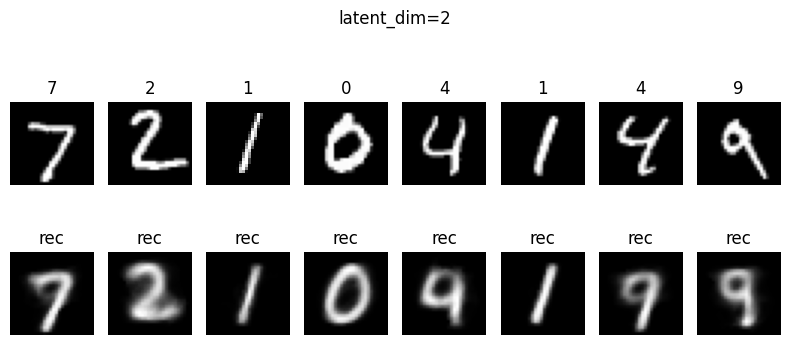

In [19]:
#1: latent_dim = 2 

torch.manual_seed(MY_SEED)
model_d2 = FCN_Autoencoder(latent_dim=2).to(device)

hist_d2 = train_ae(model_d2, "dim=2")
show_reconstructions(model_d2, "latent_dim=2")

[dim=64] эп  1/15 | train=0.0693, test=0.0437
[dim=64] эп  2/15 | train=0.0336, test=0.0276
[dim=64] эп  3/15 | train=0.0256, test=0.0232
[dim=64] эп  4/15 | train=0.0220, test=0.0200
[dim=64] эп  5/15 | train=0.0192, test=0.0174
[dim=64] эп  6/15 | train=0.0170, test=0.0163
[dim=64] эп  7/15 | train=0.0156, test=0.0147
[dim=64] эп  8/15 | train=0.0146, test=0.0142
[dim=64] эп  9/15 | train=0.0137, test=0.0132
[dim=64] эп 10/15 | train=0.0130, test=0.0125
[dim=64] эп 11/15 | train=0.0124, test=0.0120
[dim=64] эп 12/15 | train=0.0118, test=0.0114
[dim=64] эп 13/15 | train=0.0113, test=0.0110
[dim=64] эп 14/15 | train=0.0109, test=0.0106
[dim=64] эп 15/15 | train=0.0105, test=0.0102


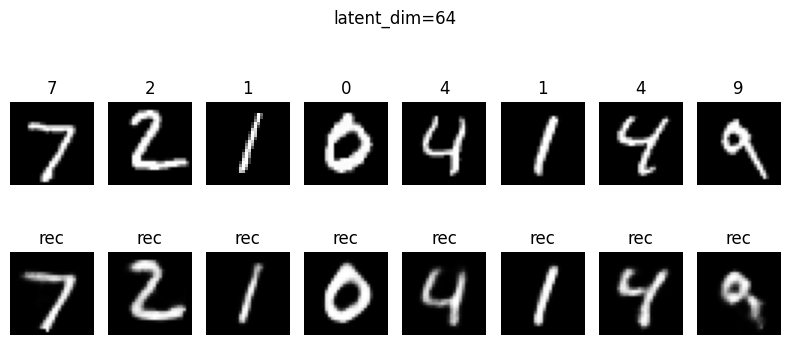

In [20]:
#2: latent_dim = 64

torch.manual_seed(MY_SEED)
model_d64 = FCN_Autoencoder(latent_dim=64).to(device)

hist_d64 = train_ae(model_d64, "dim=64")
show_reconstructions(model_d64, "latent_dim=64")

[AE_v2] эп  1/15 | train=0.0536, test=0.0317
[AE_v2] эп  2/15 | train=0.0279, test=0.0233
[AE_v2] эп  3/15 | train=0.0228, test=0.0203
[AE_v2] эп  4/15 | train=0.0206, test=0.0182
[AE_v2] эп  5/15 | train=0.0187, test=0.0165
[AE_v2] эп  6/15 | train=0.0172, test=0.0154
[AE_v2] эп  7/15 | train=0.0163, test=0.0146
[AE_v2] эп  8/15 | train=0.0156, test=0.0140
[AE_v2] эп  9/15 | train=0.0150, test=0.0134
[AE_v2] эп 10/15 | train=0.0146, test=0.0135
[AE_v2] эп 11/15 | train=0.0143, test=0.0129
[AE_v2] эп 12/15 | train=0.0140, test=0.0125
[AE_v2] эп 13/15 | train=0.0137, test=0.0125
[AE_v2] эп 14/15 | train=0.0135, test=0.0122
[AE_v2] эп 15/15 | train=0.0133, test=0.0120


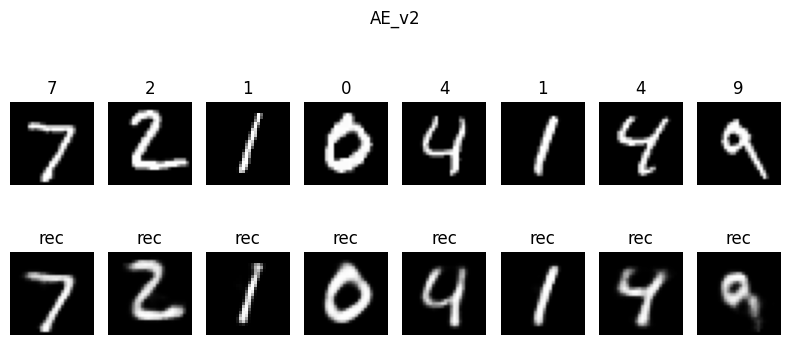

In [21]:
#3: изменённая архитектура

class FCN_AE_v2(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.1),
            nn.Linear(64, 256),
            nn.LeakyReLU(0.1),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z).view(-1, 1, 28, 28)
        return x_rec, z


torch.manual_seed(MY_SEED)
model_v2 = FCN_AE_v2(latent_dim=16).to(device)

hist_v2 = train_ae(model_v2, "AE_v2")
show_reconstructions(model_v2, "AE_v2")

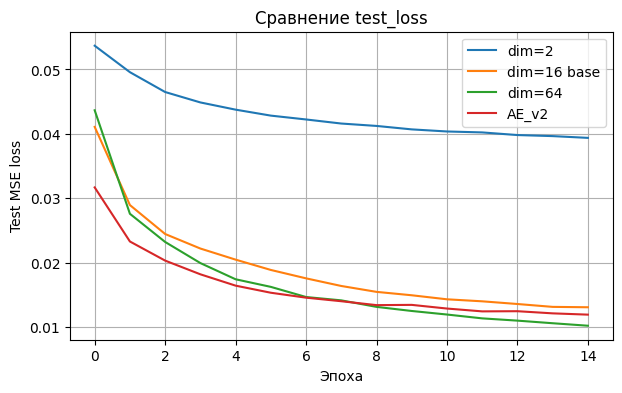

Итоговый test_loss:
dim=2: 0.0394
dim=16 base: 0.0131
dim=64: 0.0102
AE_v2: 0.0120


In [22]:
#Общее сравнение

histories = {
    "dim=2": hist_d2,
    "dim=16 base": {
        "train": history["train_loss"],
        "test": history["test_loss"]
    },
    "dim=64": hist_d64,
    "AE_v2": hist_v2
}

plot_loss_compare(histories)

print("Итоговый test_loss:")
for name, hist in histories.items():
    print(f"{name}: {hist['test'][-1]:.4f}")

In [23]:
final_summary = """
В ходе экспериментов я сравнила несколько вариантов автоэнкодера. 
1) При очень сильном сжатии (latent_dim=2) качество заметно ухудшилось: итоговый test_loss составил 0.0394,
а реконструкции стали более размытыми и потеряли часть деталей.

2) При latent_dim=16 показала намного лучший результат - test_loss=0.0131.
Увеличение latent_dim до 64 дало лучший результат среди всех вариантов:
test_loss снизился до 0.0102, а реконструкции стали более чёткими.

3) Также я попробовала изменить архитектуру, добавив BatchNorm, LeakyReLU и Dropout.
Модель AE_v2 показала test_loss=0.0120, что немного лучше базовой версии, но хуже,
чем вариант с latent_dim=64.

Вывод: слишком маленькое латентное пространство приводит к потере
важной информации. Увеличение latent_dim обычно улучшает качество восстановления,
но после определённого момента выигрыш становится небольшим. Для похожих задач я бы
начала с latent_dim около 16–64 и только потом экспериментировала с более сложной архитектурой.
"""
print(final_summary)

КОГДА ВЫ СДЕЛАЕТЕ СВОИ ВАРИАЦИИ (ДРУГИЕ latent_dim И/ИЛИ
АРХИТЕКТУРУ), ИСПОЛЬЗУЙТЕ ЭТУ ЯЧЕЙКУ ДЛЯ ИТОГОВОГО РЕЗЮМЕ: какие
настройки оказались удачными, какие — нет, и какие ПРАКТИЧЕСКИЕ ПРАВИЛА
ПО РАБОТЕ С АВТОЭНКОДЕРАМИ ДЛЯ ИЗОБРАЖЕНИЙ ВЫ ДЛЯ СЕБЯ СФОРМУЛИРОВАЛИ.
